In [188]:
import numpy as np
import cupy as cp
from scipy.special import factorial
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import sys, os, time

## q2

In [278]:
N = 25
K = 1
S = 1
dir_data = f'data/N{N}_K{K}_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

q2 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q2_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            out = history[:,j,k,:,:] # working with one sample 
            out = cp.einsum('...ac,...bc->...abc', out, out) # taking outer product of spins across sites
            out = out.reshape(out.shape[0], out.shape[1]**2, out.shape[-1]) # flattening outer product matrix
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = cp.mean(out**2, axis=0) # taking permutation average of squared quadruple products
            q2_T.append(out)

            subprogress += 1
            print(f'\rq2 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    q2_T = cp.mean(cp.array(q2_T), axis=0)
    q2.append(q2_T)
q2 = cp.array(q2).get()
cp.save(f'{dir_data}/q2.npy', q2) # saving q2
print('; Done.')



q2 Progress: 100.0%; Subprogress: 100.0%; Done.


## q4 (outer-product)

In [ ]:
q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            out = history[:,j,k,:,:] # working with one sample 
            out = cp.einsum('...ac,...bc->...abc', out, out) # taking outer product of spins across sites
            out = out.reshape(out.shape[0], out.shape[1]**2, out.shape[-1]) # flattening outer product matrix
            out = cp.einsum('...ac,...bc->...abc', out, out) # taking outer product of spin-pairs (out: quadruple product)
            out = out.reshape(out.shape[0], out.shape[1]**2, out.shape[-1]) # flattening outer product matrix
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = cp.mean(out**2, axis=0) # taking permutation average of squared quadruple products
            q4_T.append(out)

            subprogress += 1
            print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

## q4 (combinations; time-step parallel)

In [283]:
N = 25
K = 1
S = 1
combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 4)))

repetitions = factorial(4)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[:,None], (repetitions.shape[0], 3))

dir_data = f'data/N{N}_K{K}_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            sample = history[:,j,k,:,:] # working with one sample 
            out = cp.ones((history.shape[0], combination_idcs.shape[0], 3)) # creating blank of ones
            for l in range(4): # listing all combinations of quadruple products
                out *= sample[:, combination_idcs[:,l], :]
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = out**2*repetitions_broadcasted # taking permutation average of squared quadruple products
            out = cp.sum(out, axis=0)/N**4
            q4_T.append(out)

            subprogress += 1
            print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

KeyboardInterrupt: 

## q4 (combinations; time-step, thermal-sample parallel)

In [ ]:
N = 10
K = 1
S = 1
dir_data = f'data/N{N}_K{K}_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')
n_thermalSamples = np.load(f'{dir_data}/history_T0.npy').shape[2]
combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 4)))

repetitions = factorial(4)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[None,:,None], (n_thermalSamples, repetitions.shape[0], 3))

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        sample = history[:,j,:,:,:] # working with one sample 
        out = cp.ones((*history.shape[:2], combination_idcs.shape[0], 3)) # creating blank of ones
        for l in range(4): # listing all combinations of quadruple products
            out *= sample[:, :, combination_idcs[:,l], :]
        out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
        out = out**2*repetitions_broadcasted # taking permutation average of squared quadruple products
        out = cp.sum(out, axis=1)/N**4
        out = cp.mean(out, axis=0)
        q4_T.append(out)

        subprogress += 1
        print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1], 2)}%', end='')
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

q4 Progress: 100.0%; Subprogress: 1.0%%; Done.


## Binder

In [279]:
Uq = (1 - q4/q2**2/3)*3/2
np.save(f'{dir_data}/Uq.npy', Uq)

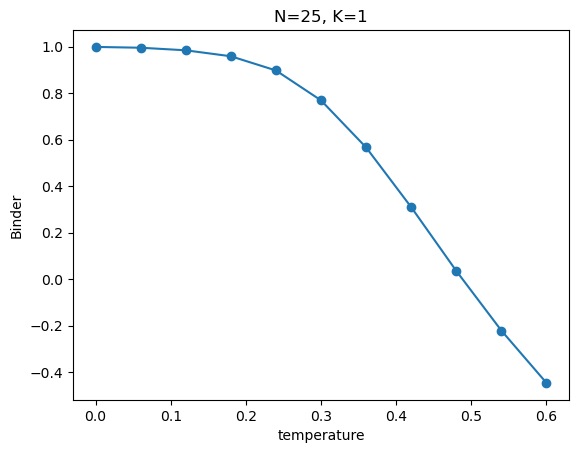

In [280]:
plt.plot(T_vals, Uq[:,2], marker='o')
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.title('N=25, K=1')
plt.savefig('Binder_q2.png')

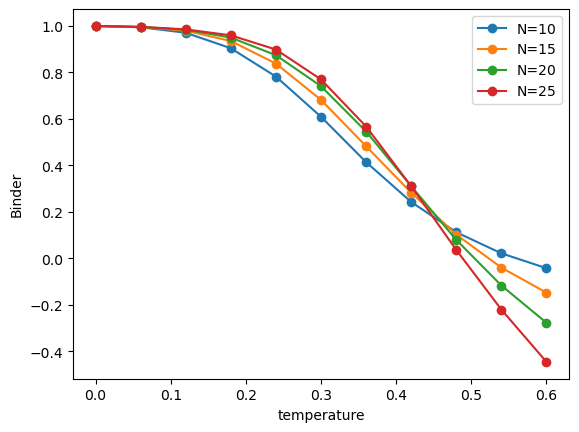

In [282]:
T_vals = np.load('data/N10_K1_S1/T_vals.npy')
# plt.plot(T_vals, np.load('data/N5_K1_S1/Uq.npy')[:,2], marker='o', label='N=5')
plt.plot(T_vals, np.load('data/N10_K1_S1/Uq.npy')[:,2], marker='o', label='N=10')
plt.plot(T_vals, np.load('data/N15_K1_S1/Uq.npy')[:,2], marker='o', label='N=15')
plt.plot(T_vals, np.load('data/N20_K1_S1/Uq.npy')[:,2], marker='o', label='N=20')
plt.plot(T_vals, np.load('data/N25_K1_S1/Uq.npy')[:,2], marker='o', label='N=25')
plt.legend()
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.savefig('Binder_q2.png')

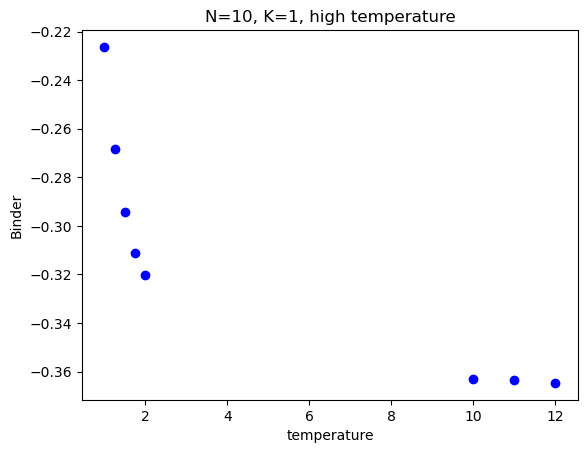

In [19]:
plt.plot(np.load('data/N10_K1_highTemp_moreDisorder_S1/T_vals.npy'), np.load('data/N10_K1_highTemp_moreDisorder_S1/Uq.npy')[:,2], 'bo')
plt.plot(np.load('data/N10_K1_superHighTemp_S1/T_vals.npy'), np.load('data/N10_K1_superHighTemp_S1/Uq.npy')[:,2], 'bo')
plt.xlabel('temperature')
plt.ylabel('Binder')
plt.title('N=10, K=1, high temperature')
plt.savefig('Binder_highTemp.png')

# Listing combinations (time-step parallel)

In [276]:
N = 25
K = 1
S = 1
combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 4)))

repetitions = factorial(4)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[:,None], (repetitions.shape[0], 3))

dir_data = f'data/N{N}_K{K}_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        for k in range(history.shape[2]):
            sample = history[:,j,k,:,:] # working with one sample 
            out = cp.ones((history.shape[0], combination_idcs.shape[0], 3)) # creating blank of ones
            for l in range(4): # listing all combinations of quadruple products
                out *= sample[:, combination_idcs[:,l], :]
            out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
            out = out**2*repetitions_broadcasted # taking permutation average of squared quadruple products
            out = cp.sum(out, axis=0)/N**4
            q4_T.append(out)

            subprogress += 1
            print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1]/history.shape[2], 2)}%', end='')
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

q4 Progress: 100.0%; Subprogress: 100.0%; Done.


# Through listing comnbinations (time-step, thermal sample parallel)

In [ ]:
N = 10
K = 1
S = 1
combination_idcs = np.array(list(combinations_with_replacement(np.arange(N), 4)))

repetitions = factorial(4)*np.ones(combination_idcs.shape[0])
for i, combination in enumerate(combination_idcs):
    repetitions[i] /= np.prod(factorial(np.unique(combination, return_counts=True)[1]))
repetitions = repetitions.astype(int)
repetitions_broadcasted = cp.broadcast_to(cp.array(repetitions)[None,:,None], (100,repetitions.shape[0], 3))

dir_data = f'data/N{N}_K{K}_S{S}'
T_vals = np.load(f'{dir_data}/T_vals.npy')

q4 = []
for i in range(len(T_vals)):
    history = cp.load(f'{dir_data}/history_T{i}.npy') # loading history of spins
    q4_T = []
    subprogress = 0
    for j in range(history.shape[1]):
        sample = history[:,j,:,:,:] # working with one sample 
        out = cp.ones((*history.shape[:2], combination_idcs.shape[0], 3)) # creating blank of ones
        for l in range(4): # listing all combinations of quadruple products
            out *= sample[:, :, combination_idcs[:,l], :]
        out = cp.mean(out, axis=0) # taking time average (thermal ave. if ergodic)
        out = out**2*repetitions_broadcasted # taking permutation average of squared quadruple products
        out = cp.sum(out, axis=1)/N**4
        out = cp.mean(out, axis=0)
        q4_T.append(out)

        subprogress += 1
        print(f'\rq4 Progress: {np.round(100*(i+1)/len(T_vals), 2)}%; Subprogress: {np.round(100*subprogress/history.shape[1], 2)}%', end='')
    q4_T = cp.mean(cp.array(q4_T), axis=0)
    q4.append(q4_T)
q4 = cp.array(q4).get()
cp.save(f'{dir_data}/q4.npy', q4) # saving q4
print('; Done.')

q4 Progress: 100.0%; Subprogress: 1.0%%; Done.


In [273]:
q2 = np.load(f'{dir_data}/q2.npy')
q4_ref = np.load(f'{dir_data}/q4.npy')

In [274]:
U = (1 - q4/q2**2/3)*3/2
U_ref = (1 - q4_ref/q2**2/3)*3/2

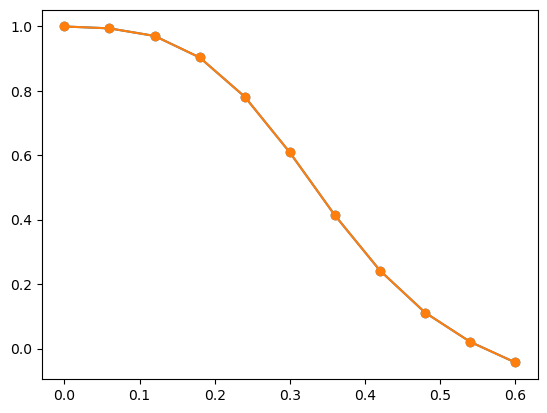

In [275]:
plt.plot(T_vals, U[:,2], marker='o')
plt.plot(T_vals, U_ref[:,2], marker='o')

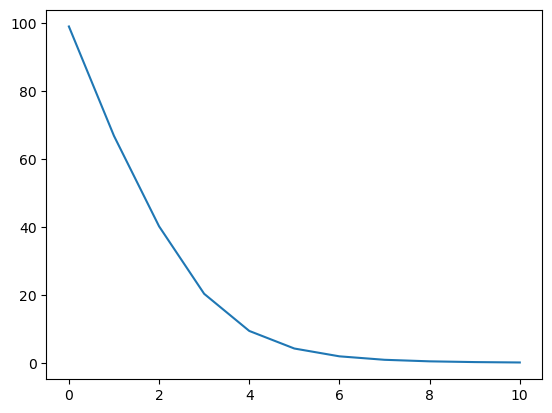

In [271]:
plt.plot(q4[:,2])